Importing Libraries

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

Loading Dataset

In [ ]:
cols = ["letter","x-box","y-box","width","height","onpix","x-bar","y-bar",
        "x2bar","y2bar","xybar","x2ybr","xy2br","x-ege","xegvy","y-ege","yegvx"]

df = pd.read_csv("../data/letter-recognition.data", names=cols)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   letter  20000 non-null  str  
 1   x-box   20000 non-null  int64
 2   y-box   20000 non-null  int64
 3   width   20000 non-null  int64
 4   height  20000 non-null  int64
 5   onpix   20000 non-null  int64
 6   x-bar   20000 non-null  int64
 7   y-bar   20000 non-null  int64
 8   x2bar   20000 non-null  int64
 9   y2bar   20000 non-null  int64
 10  xybar   20000 non-null  int64
 11  x2ybr   20000 non-null  int64
 12  xy2br   20000 non-null  int64
 13  x-ege   20000 non-null  int64
 14  xegvy   20000 non-null  int64
 15  y-ege   20000 non-null  int64
 16  yegvx   20000 non-null  int64
dtypes: int64(16), str(1)
memory usage: 2.6 MB


Exploratory Data Analysis

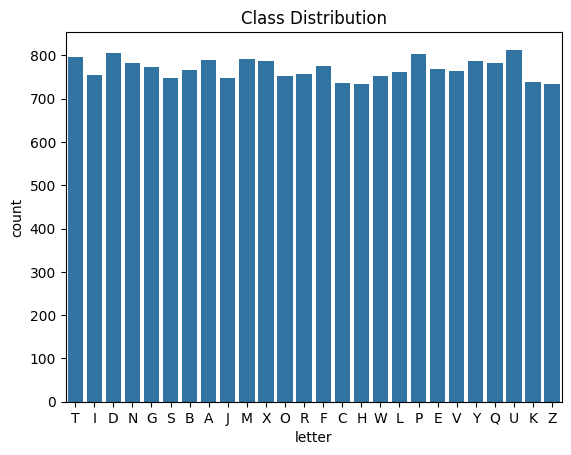

In [17]:
sns.countplot(x='letter', data=df)
plt.title('Class Distribution')
plt.show()

Data Preprocessing

In [18]:
X = df.drop('letter', axis=1)
y = df['letter']

# Label Encoding
le = LabelEncoder()
y = le.fit_transform(y)

# train and test data split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# feature scaling.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# one hot encoding.
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

Model Building

In [23]:
model = Sequential()

model.add(Dense(512, activation='relu', input_shape=(16,)))
model.add(Dropout(0.4))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(26, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/Users/parimal/VisualStudioCodeProjects/dl-assignments/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Training

In [24]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4715 - loss: 1.7545 - val_accuracy: 0.7494 - val_loss: 0.8736
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6927 - loss: 0.9851 - val_accuracy: 0.8197 - val_loss: 0.6224
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7527 - loss: 0.7873 - val_accuracy: 0.8562 - val_loss: 0.4967
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7867 - loss: 0.6667 - val_accuracy: 0.8719 - val_loss: 0.4163
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8098 - loss: 0.5987 - val_accuracy: 0.8981 - val_loss: 0.3604
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8258 - loss: 0.5469 - val_accuracy: 0.9053 - val_loss: 0.3212
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8445 - loss: 0.4830 - val_accuracy: 0.9072 - val_loss: 0.2896
Epoch 8/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8571 - loss: 0.4577 - val_accu

Training Vs Validation Loss

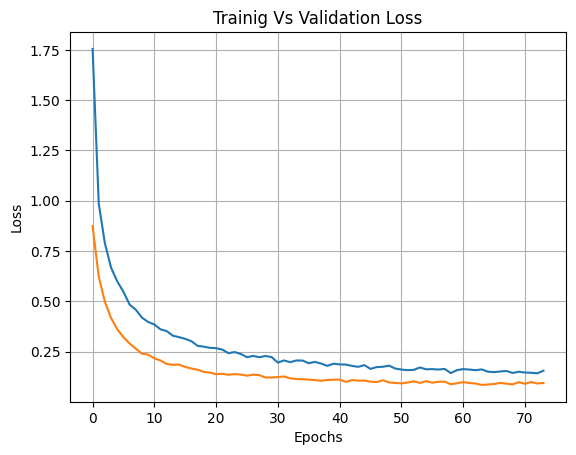

In [25]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Trainig Vs Validation Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.show()

Prediction and Evaluation

In [31]:
# Predict probabilities for each class
# Example: [[0.1, 0.7, 0.2], [0.8, 0.1, 0.1]]
y_pred = model.predict(X_test)

# Convert probabilities → predicted class indices
# Example: [0.1, 0.7, 0.2] → 1  (index of max value)
# Result: [1, 0]
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert one-hot actual labels → class indices
# Example: [0,1,0] → 1 , [1,0,0] → 0
# Result: [1, 0]
y_true = np.argmax(y_test, axis=1)

# Compare predicted vs actual → compute accuracy
# Example: y_true = [1,0], y_pred = [1,0] → Accuracy = 2/2 = 1.0
print('Accuracy Score: ', accuracy_score(y_true, y_pred_classes))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 354us/step
Accuracy Score:  0.973


Confusion Matrix

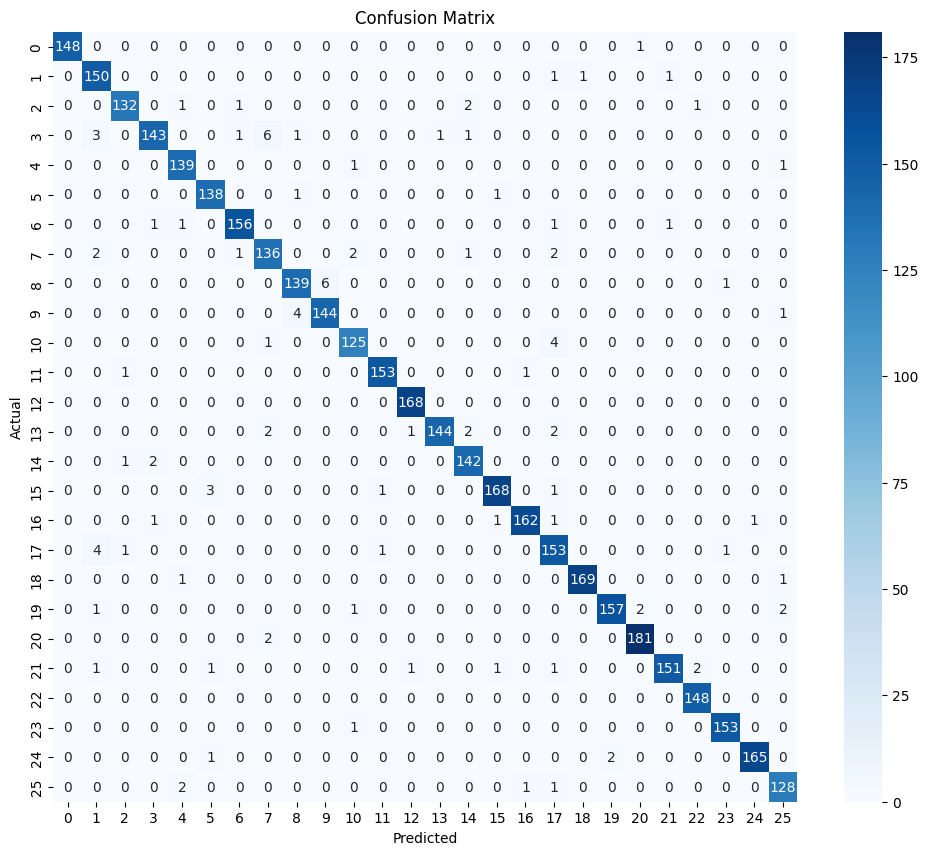

In [41]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()